In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, top_k_accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Load the processed dataframe
df_clean = pd.read_csv("../dataset/processed/processed_travel_data.csv")

# Recreate necessary variables (as done in data_preprocessing.ipynb)
le_dest = LabelEncoder()
df_clean['Target_Destination'] = le_dest.fit_transform(df_clean['DestinationName'])

numeric_features = ['Age', 'NumberOfAdults', 'NumberOfChildren', 'TravelMonth', 'Avg_Dest_Rating', 'Review_Count', 'Preference_Match_Score', 'Family_Size', 'Budget_Score']
categorical_features = ['Gender', 'Budget', 'Pref_Relaxation', 'Pref_Adventure', 'Pref_Culture', 'Pref_Spiritual', 'TravelSeason', 'Age_Group', 'Has_Children', 'Seasonal_Match']

X = df_clean[numeric_features + categorical_features]
y = df_clean['Target_Destination']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Recreate preprocessors
preprocessor_enhanced = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

preprocessor = preprocessor_enhanced

preprocessor_unscaled = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

results_dict = {}

print("Processed data loaded and variables set up.")

Processed data loaded and variables set up.


# Model Selection


---
## 4. Initial Evaluation

## Model Selection

#### Initial Logistic Regression

/home/erxanitea/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/erxanitea/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/erxanitea/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/erxanitea/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'm

,Accuracy,Precision,Recall,F1-Score,CV-F1,Top3-Acc
Initial Logistic Regression,0.77459,0.758333,0.77459,0.761149,0.740382,0.897541


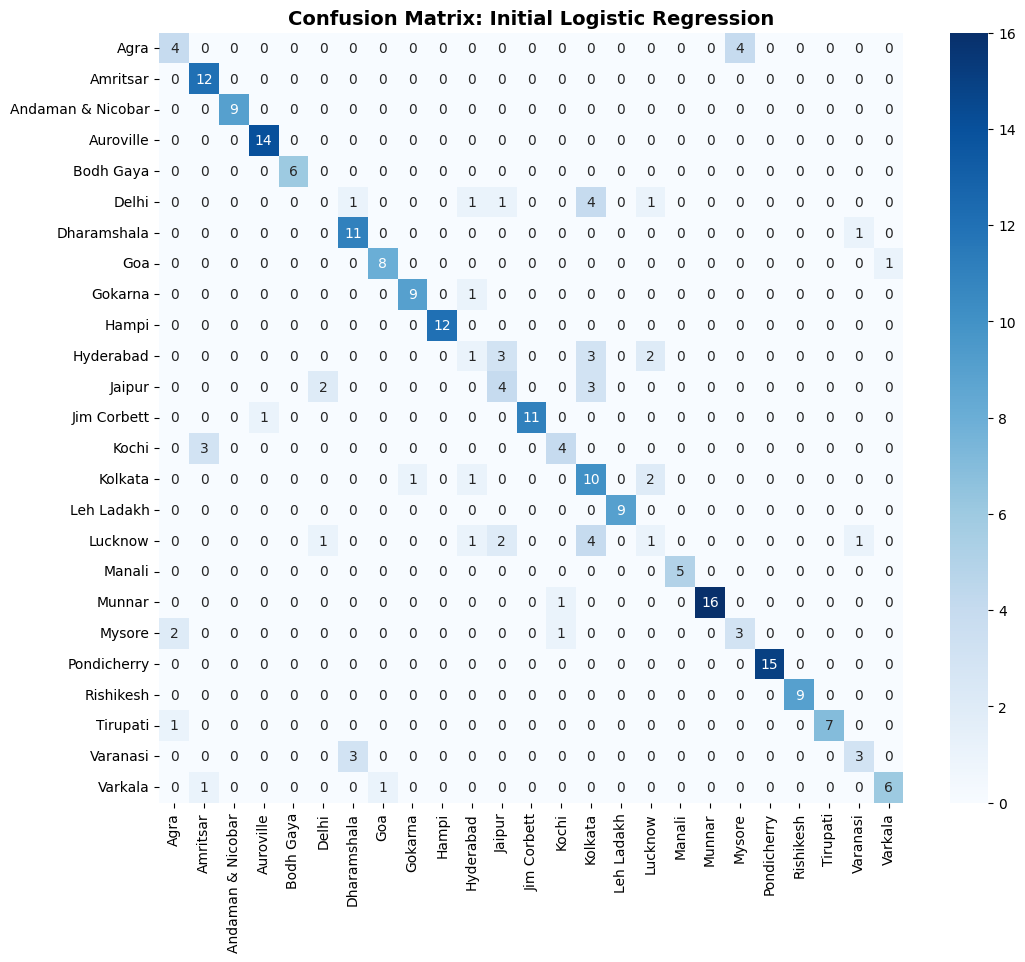

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

pipe = Pipeline([('preprocessor', preprocessor), ('clf', LogisticRegression(multi_class='multinomial', random_state=42))])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'CV-F1': cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1_weighted').mean(),
    'Top3-Acc': top_k_accuracy_score(y_test, y_prob, k=3)
}
results_dict['Initial Logistic Regression'] = metrics
display(pd.DataFrame([metrics], index=['Initial Logistic Regression']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_dest.classes_, yticklabels=le_dest.classes_)
plt.title('Confusion Matrix: Initial Logistic Regression', fontsize=14, fontweight='bold')
plt.show()

#### Initial Random Forest

In [3]:
pipe = Pipeline([('preprocessor', preprocessor_unscaled), ('clf', RandomForestClassifier(random_state=42))])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'CV-F1': cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1_weighted').mean(),
    'Top3-Acc': top_k_accuracy_score(y_test, y_prob, k=3)
}
results_dict['Initial Random Forest'] = metrics
display(pd.DataFrame([metrics], index=['Initial Random Forest']))

,Accuracy,Precision,Recall,F1-Score,CV-F1,Top3-Acc
Initial Random Forest,0.737705,0.741529,0.737705,0.733885,0.728445,0.909836


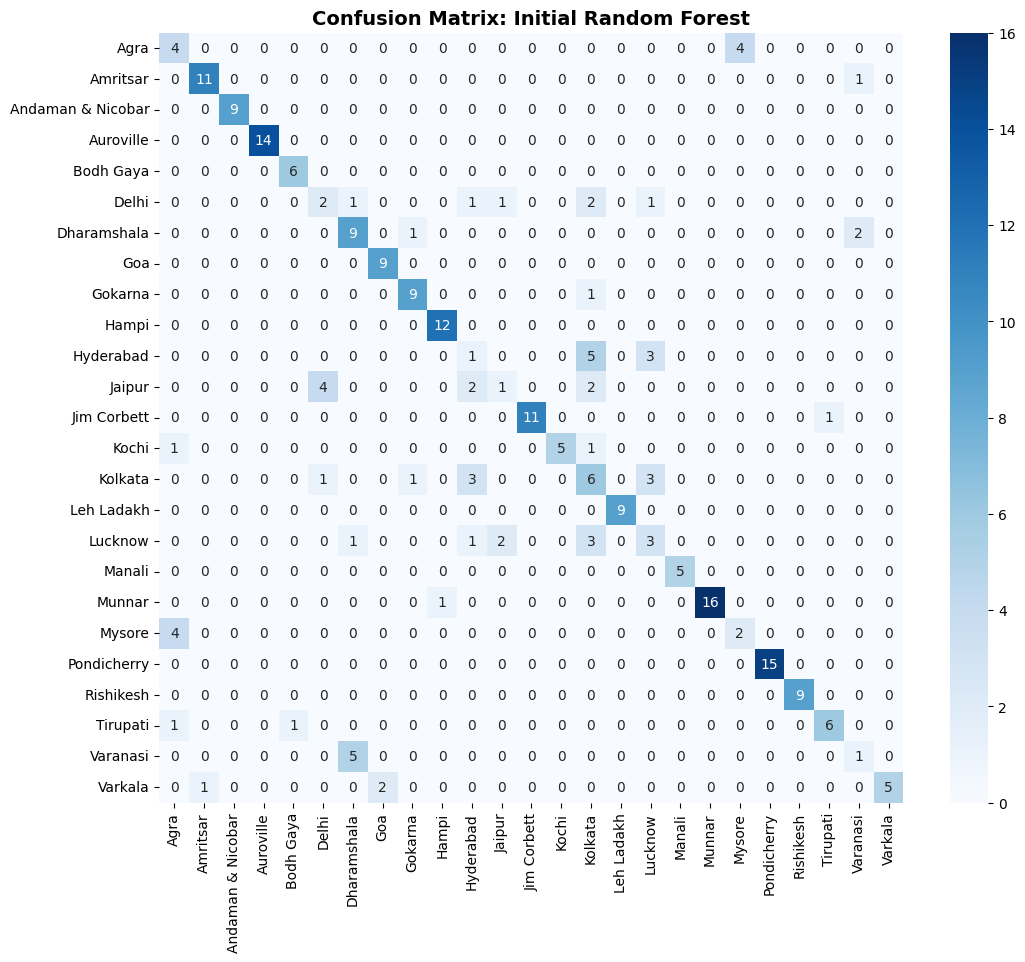

In [4]:
# Confusion Matrix for Initial Random Forest
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_dest.classes_, yticklabels=le_dest.classes_)
plt.title('Confusion Matrix: Initial Random Forest', fontsize=14, fontweight='bold')
plt.show()

### Feature Importance Analysis

Optimized Logistic Regression model loaded successfully.


/tmp/ipykernel_9404/3277308675.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis', edgecolor='black', alpha=0.9)


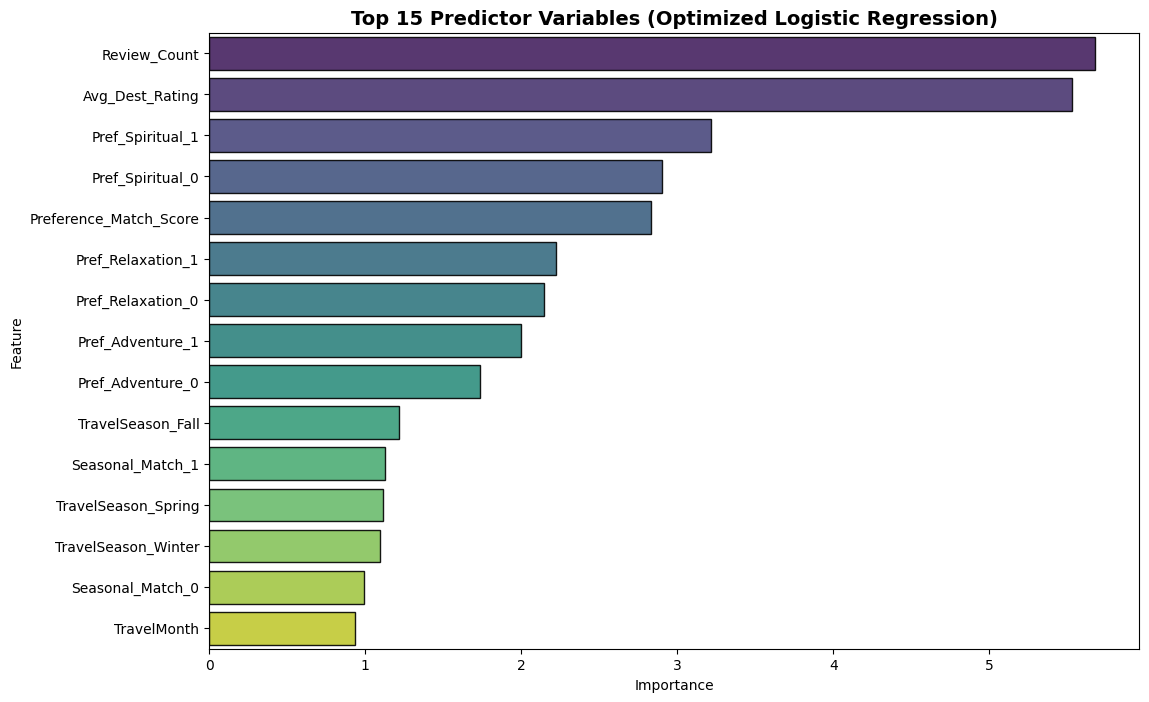

In [5]:
import joblib

# Load optimized models for feature importance
try:
    lr_opt = joblib.load("../models/optimized_logistic_regression_travel.pkl")
    print("Optimized Logistic Regression model loaded successfully.")
except FileNotFoundError:
    print("Warning: Optimized Logistic Regression model not found. Please run hyperparameter_tuning.ipynb first.")
    lr_opt = None

if lr_opt is not None:
    importances = np.abs(lr_opt.named_steps['clf'].estimators_[0].coef_).mean(axis=0)  # Use first estimator (multinomial LR) coefficients
    ohe = lr_opt.named_steps['preprocessor'].named_transformers_['cat']
    feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))
    feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False).head(15)
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis', edgecolor='black', alpha=0.9)
    plt.title('Top 15 Predictor Variables (Optimized Logistic Regression)', fontsize=14, fontweight='bold')
    plt.show()
else:
    print("Skipping feature importance plot for Logistic Regression.")

Optimized Random Forest model loaded successfully.


/tmp/ipykernel_9404/3660417499.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df_rf, x='Importance', y='Feature', palette='plasma', edgecolor='black', alpha=0.9)


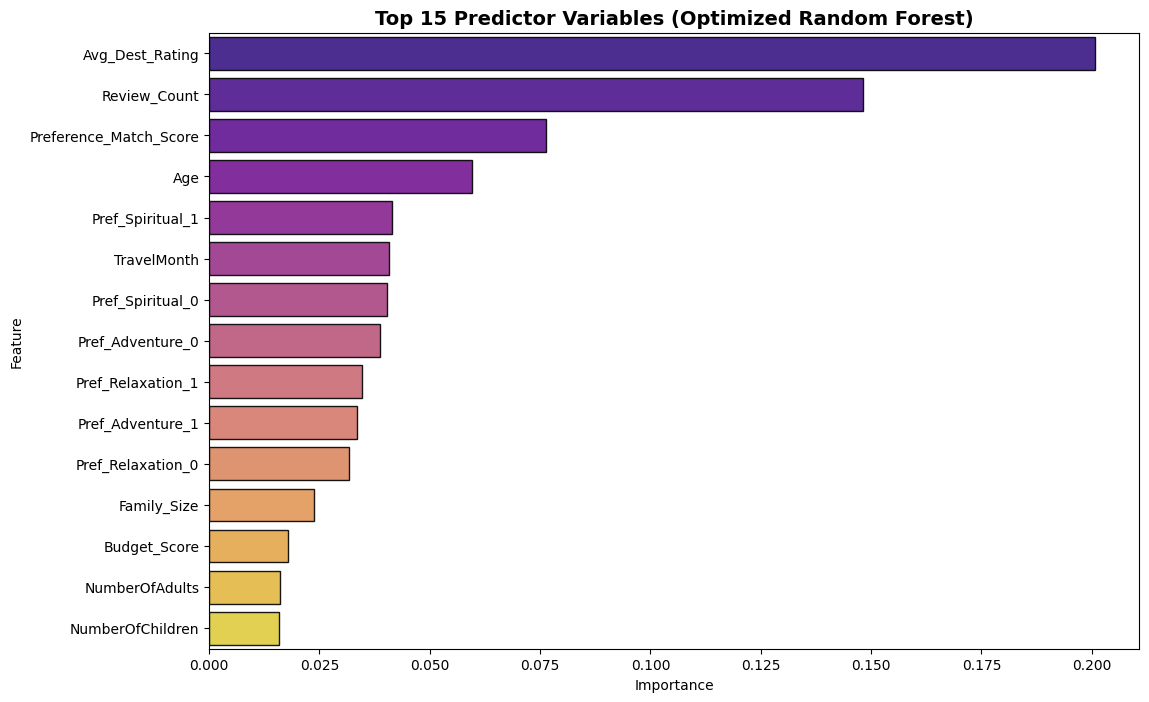

In [6]:
# Load optimized models for feature importance
try:
    rf_opt = joblib.load("../models/optimized_random_forest_travel.pkl")
    print("Optimized Random Forest model loaded successfully.")
except FileNotFoundError:
    print("Warning: Optimized Random Forest model not found. Please run hyperparameter_tuning.ipynb first.")
    rf_opt = None

if rf_opt is not None:
    # Feature Importance for Optimized Random Forest
    importances_rf = rf_opt.named_steps['clf'].feature_importances_
    ohe_rf = rf_opt.named_steps['preprocessor'].named_transformers_['cat']
    feature_names_rf = numeric_features + list(ohe_rf.get_feature_names_out(categorical_features))
    feat_df_rf = pd.DataFrame({'Feature': feature_names_rf, 'Importance': importances_rf}).sort_values('Importance', ascending=False).head(15)
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feat_df_rf, x='Importance', y='Feature', palette='plasma', edgecolor='black', alpha=0.9)
    plt.title('Top 15 Predictor Variables (Optimized Random Forest)', fontsize=14, fontweight='bold')
    plt.show()
else:
    print("Skipping feature importance plot for Random Forest.")